# Imports

In [1]:
import numpy as np                      # Álgebra lineal y aleatorios
import pandas as pd                     # Manipulación de DataFrames
import json                             # Lectura de artefactos (config, features)
import joblib                           # Serialización de modelos
import matplotlib.pyplot as plt         # Visualización estática
import matplotlib.ticker as mticker     # Formateo de ejes
import seaborn as sns                   # Visualización estadística
from sklearn.metrics import (           # Métricas de clasificación
    fbeta_score, f1_score, precision_score, recall_score,
    average_precision_score, roc_auc_score, brier_score_loss,
    confusion_matrix, classification_report, precision_recall_curve, roc_curve
)
from sklearn.model_selection import StratifiedKFold, cross_validate  # Validación cruzada
from sklearn.metrics import make_scorer               # Scorer personalizado (F2)
from scipy import stats                 # Distribuciones estadísticas (t-Student)
import warnings, os, time               # Utilidades del sistema
warnings.filterwarnings('ignore')       # Silenciar warnings irrelevantes

# Estilo visual global
sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120

SEED = 42                               # Semilla para reproducibilidad
np.random.seed(SEED)                    # Fijar semilla NumPy
F2_SCORER = make_scorer(fbeta_score, beta=2)  # Métrica de decisión del proyecto (F2)

# Rutas

In [2]:
BASE = os.path.dirname(os.path.abspath('.'))               # Raíz del proyecto
NBK  = os.path.join(BASE, 'notebooks')                      # Carpeta de notebooks
S0   = os.path.join(NBK, 'outputs_sprint0', 'data')         # Datos base + índices del split
S2D  = os.path.join(NBK, 'outputs_sprint2', 'data')         # Matrices de features (parquet)
S3D  = os.path.join(NBK, 'outputs_sprint3', 'data')         # Features seleccionadas del sprint 3
OUT_DIR = os.path.join(NBK, 'outputs_sprint4_comparativo')  # Salidas de este comparativo
os.makedirs(OUT_DIR, exist_ok=True)                         # Crear carpeta si no existe

# Resúmenes de cada sprint (para trazar la evolución del MISMO modelo, XGBoost, S0 -> S4)
RESUMEN = {s: os.path.join(NBK, f'outputs_sprint{s}', f'resumen_sprint{s}.json') for s in range(5)}

# Modelos XGBoost guardados en cada sprint (el modelo ganador del proyecto en su versión por sprint)
MODELOS_XGB = {
    0: os.path.join(NBK, 'outputs_sprint0', 'models', 'modelo_XGBoost.pkl'),
    1: os.path.join(NBK, 'outputs_sprint1', 'models', 'modelo_XGBoost.pkl'),
    2: os.path.join(NBK, 'outputs_sprint2', 'models', 'modelo_xgboost.pkl'),
    3: os.path.join(NBK, 'outputs_sprint3', 'models', 'modelo_calibrado_xgboost.pkl'),
    4: os.path.join(NBK, 'outputs_sprint4', 'models', 'modelo_campeon_final.pkl'),
}
print('Recursos por sprint (resumen | modelo XGBoost):')
for s in range(5):
    ok_r = 'OK' if os.path.exists(RESUMEN[s]) else 'FALTA'
    ok_m = 'OK' if os.path.exists(MODELOS_XGB[s]) else 'FALTA'
    print(f'  S{s}: resumen={ok_r} | modelo={ok_m}')
print(f'OUT: {OUT_DIR}')

Recursos por sprint (resumen | modelo XGBoost):
  S0: resumen=OK | modelo=OK
  S1: resumen=OK | modelo=OK
  S2: resumen=OK | modelo=OK
  S3: resumen=OK | modelo=OK
  S4: resumen=OK | modelo=OK
OUT: /workspaces/proyecto-zona-interes-Au/notebooks/outputs_sprint4_comparativo


# Carga de datos

In [3]:
# Datos base e índices del split estratificado (idénticos en todos los sprints)
df_raw = pd.read_csv(os.path.join(S0, 'data_procesada.csv'))
idx_train = np.load(os.path.join(S0, 'idx_train.npy'))
idx_test  = np.load(os.path.join(S0, 'idx_test.npy'))
y_train = df_raw.loc[idx_train, 'target_Au'].reset_index(drop=True)
y_test  = df_raw.loc[idx_test,  'target_Au'].reset_index(drop=True)

# Matrices de features del sprint 2 (E2 = base+cluster, 45 cols; E3 = superconjunto, 63 cols)
X_E2_test = pd.read_parquet(os.path.join(S2D, 'X_E2_test.parquet'))
X_E3_test = pd.read_parquet(os.path.join(S2D, 'X_E3_test.parquet'))

# Features usadas por XGBoost en cada etapa:
#  - S0 y S1 operaron sobre las 43 features crudas (el pipeline S1 hace PCA/balanceo internamente)
#  - S2 usó el set E2 + cluster (45 features)
#  - S3 y S4 usan las 28 features seleccionadas por SHAP (1-SE)
FEATS_RAW = json.load(open(RESUMEN[0]))['features']                 # 43 features crudas (S0/S1)
FEATS_S3  = json.load(open(os.path.join(S3D, 'features_s3_por_modelo.json')))['XGBoost']  # 28 (S3/S4)

# Umbral de decisión aplicado por XGBoost en cada sprint (F2 es la métrica de decisión)
r3 = json.load(open(RESUMEN[3])); r4 = json.load(open(RESUMEN[4]))
THR = {
    0: 0.5,                                              # S0: sin balanceo, umbral por defecto
    1: 0.5,                                              # S1: SMOTE, umbral por defecto
    2: 0.5,                                              # S2: SMOTE + Optuna, umbral por defecto
    3: r3['umbral'],                                     # S3: umbral anidado sobre modelo calibrado
    4: r4['calibracion_umbral']['umbral_global_nested'], # S4: umbral GLOBAL anidado (campeón)
}
print(f'Test: {X_E3_test.shape[0]} muestras | positivos={int(y_test.sum())}/{len(y_test)} ({y_test.mean():.1%})')
print(f'Features: crudas(S0/S1)={len(FEATS_RAW)} | E2(S2)={X_E2_test.shape[1]} | SHAP(S3/S4)={len(FEATS_S3)}')
print('Umbrales XGBoost por sprint:', {f"S{s}": round(t, 4) for s, t in THR.items()})

Test: 427 muestras | positivos=52/427 (12.2%)
Features: crudas(S0/S1)=43 | E2(S2)=45 | SHAP(S3/S4)=28
Umbrales XGBoost por sprint: {'S0': 0.5, 'S1': 0.5, 'S2': 0.5, 'S3': 0.1633, 'S4': 0.1842}


# Carga de modelos

In [4]:
# Se cargan las 5 versiones del MISMO modelo (XGBoost) tal como quedaron en cada sprint.
# Cada entrada: (modelo, features, umbral, fuente_X). El baseline S0/S1 usa las features crudas
# desde df_raw; S2 el set E2; S3/S4 las 28 features SHAP tomadas del superconjunto E3.
xgb_versiones = {
    'S0 · Baseline':        (joblib.load(MODELOS_XGB[0]), FEATS_RAW, THR[0], 'raw'),
    'S1 · Balanceo':        (joblib.load(MODELOS_XGB[1]), FEATS_RAW, THR[1], 'raw'),
    'S2 · FE + Optuna':     (joblib.load(MODELOS_XGB[2]), None,      THR[2], 'e2'),
    'S3 · Calib. + SHAP':   (joblib.load(MODELOS_XGB[3]), FEATS_S3,  THR[3], 'e3'),
    'S4 · Campeón':         (joblib.load(MODELOS_XGB[4]), FEATS_S3,  THR[4], 'e3'),
}
for nombre, (mdl, feats, thr, src) in xgb_versiones.items():
    tipo = type(mdl).__name__
    nfeat = (mdl.n_features_in_ if feats is None else len(feats))
    print(f'  {nombre:22s}: {tipo:22s} | {nfeat} features | umbral={thr:.4f}')

  S0 · Baseline         : Pipeline               | 43 features | umbral=0.5000
  S1 · Balanceo         : Pipeline               | 43 features | umbral=0.5000
  S2 · FE + Optuna      : Pipeline               | 45 features | umbral=0.5000
  S3 · Calib. + SHAP    : CalibratedClassifierCV | 28 features | umbral=0.1633
  S4 · Campeón          : CalibratedClassifierCV | 28 features | umbral=0.1842


# Predicciones en conjunto de prueba

In [5]:
# Predicciones de cada versión de XGBoost sobre EL MISMO hold-out (427 muestras, 52 positivos).
# Todas las versiones escalan/transforman internamente; sólo cambian features, umbral y fuente de X.
def _X_para(src, feats):
    if src == 'raw':
        return df_raw.loc[idx_test, feats]
    if src == 'e2':
        return X_E2_test
    return X_E3_test[feats]

resultados_pred = {}
for nombre, (modelo, feats, thr, src) in xgb_versiones.items():
    X_src = _X_para(src, feats)
    y_prob = modelo.predict_proba(X_src)[:, 1]
    y_pred = (y_prob >= thr).astype(int)
    resultados_pred[nombre] = {'y_pred': y_pred, 'y_prob': y_prob}
    print(f'{nombre:22s}: positivos predichos = {int(y_pred.sum())}/{len(y_pred)} (umbral={thr:.4f})')

S0 · Baseline         : positivos predichos = 34/427 (umbral=0.5000)
S1 · Balanceo         : positivos predichos = 65/427 (umbral=0.5000)
S2 · FE + Optuna      : positivos predichos = 64/427 (umbral=0.5000)
S3 · Calib. + SHAP    : positivos predichos = 104/427 (umbral=0.1633)
S4 · Campeón          : positivos predichos = 97/427 (umbral=0.1842)


# Verificación del modelo final del sprint 4

In [6]:
# Cada versión reconstruida debe reproducir la métrica hold-out que su sprint registró.
ref_holdout = {
    'S1 · Balanceo':      json.load(open(RESUMEN[1]))['f2_holdout_por_modelo']['XGBoost'],
    'S2 · FE + Optuna':   json.load(open(RESUMEN[2]))['metricas_holdout']['F2'],
    'S3 · Calib. + SHAP': json.load(open(RESUMEN[3]))['metricas_holdout']['F2'],
    'S4 · Campeón':       json.load(open(RESUMEN[4]))['metricas_holdout']['F2'],
}
print('Verificación de reconstrucción (F2 hold-out reconstruido vs registrado en cada sprint):')
for nombre, f2_ref in ref_holdout.items():
    f2_rec = fbeta_score(y_test, resultados_pred[nombre]['y_pred'], beta=2, zero_division=0)
    marca = 'OK' if abs(f2_rec - f2_ref) < 1e-3 else 'REVISAR'
    print(f'  {nombre:22s}: reconstruido={f2_rec:.4f} | registrado={f2_ref:.4f} -> {marca}')
    assert abs(f2_rec - f2_ref) < 1e-3, f'{nombre} no reproduce su F2 hold-out'

# El campeón S4 además reproduce EXACTAMENTE las probabilidades finales guardadas en el sprint 4
saved = pd.read_csv(os.path.join(NBK, 'outputs_sprint4', 'data', 'predicciones_holdout.csv'))
p_champ = resultados_pred['S4 · Campeón']['y_prob']
max_diff = float(np.max(np.abs(p_champ - saved['p_final'].values)))
print(f'\nCampeón S4: máx. diferencia vs predicciones_holdout.csv = {max_diff:.2e}')
assert max_diff < 1e-6, 'El campeón no reproduce las probabilidades finales del sprint 4'
print('OK: las 5 versiones de XGBoost quedan verificadas sobre el mismo hold-out')

Verificación de reconstrucción (F2 hold-out reconstruido vs registrado en cada sprint):
  S1 · Balanceo         : reconstruido=0.7143 | registrado=0.7143 -> OK
  S2 · FE + Optuna      : reconstruido=0.6985 | registrado=0.6985 -> OK
  S3 · Calib. + SHAP    : reconstruido=0.6891 | registrado=0.6891 -> OK
  S4 · Campeón          : reconstruido=0.7049 | registrado=0.7049 -> OK

Campeón S4: máx. diferencia vs predicciones_holdout.csv = 1.11e-16
OK: las 5 versiones de XGBoost quedan verificadas sobre el mismo hold-out


# Funcion de evaluación global con BOOTSTRAP IC 95%

In [7]:
def evaluar_global_bootstrap(y_true, y_prob, y_pred, n_boot=1000, conf=0.95, seed=42):
    """
    Evaluación global con bootstrap para calcular intervalos de confianza robustos.
    Retorna dict con métricas puntuales + IC para F2 (decisión), F1, Precision, Recall, PR-AUC, ROC-AUC, Brier.
    """
    rng = np.random.RandomState(seed)      # Generador reproducible
    n = len(y_true)                        # Tamaño de la muestra
    alpha = (1 - conf) / 2                 # Cola inferior (ej: 0.025 para 95%)

    # Métricas puntuales (valores exactos sobre el conjunto completo)
    metrics = {
        'n': n,
        'n_pos': int(y_true.sum()),
        'n_neg': int((1 - y_true).sum()),
        'F2':        fbeta_score(y_true, y_pred, beta=2, zero_division=0),
        'Precision': precision_score(y_true, y_pred, zero_division=0),
        'Recall':    recall_score(y_true, y_pred, zero_division=0),
        'F1':        f1_score(y_true, y_pred, zero_division=0),
        'PR_AUC':    average_precision_score(y_true, y_prob),
        'ROC_AUC':   roc_auc_score(y_true, y_prob),
        'Brier':     brier_score_loss(y_true, y_prob),
    }

    # Bootstrap: remuestreo con reemplazo
    boot_metrics = {k: [] for k in ['F2', 'F1', 'Precision', 'Recall', 'PR_AUC', 'ROC_AUC', 'Brier']}
    for _ in range(n_boot):
        idx = rng.choice(n, size=n, replace=True)  # Índices aleatorios con repetición
        yt = np.array(y_true)[idx]
        yp = np.array(y_pred)[idx]
        ypr = np.array(y_prob)[idx]

        if len(np.unique(yt)) < 2:  # Evitar división por cero si solo una clase
            continue

        boot_metrics['F2'].append(fbeta_score(yt, yp, beta=2, zero_division=0))
        boot_metrics['F1'].append(f1_score(yt, yp, zero_division=0))
        boot_metrics['Precision'].append(precision_score(yt, yp, zero_division=0))
        boot_metrics['Recall'].append(recall_score(yt, yp, zero_division=0))
        boot_metrics['PR_AUC'].append(average_precision_score(yt, ypr))
        boot_metrics['ROC_AUC'].append(roc_auc_score(yt, ypr))
        boot_metrics['Brier'].append(brier_score_loss(yt, ypr))

    # Calcular percentiles para IC
    for key in boot_metrics:
        vals = np.array(boot_metrics[key])
        if len(vals) > 0:
            metrics[f'{key}_CI_low']  = np.percentile(vals, alpha * 100)
            metrics[f'{key}_CI_high'] = np.percentile(vals, (1 - alpha) * 100)
            metrics[f'{key}_std']     = np.std(vals)
        else:
            metrics[f'{key}_CI_low'] = metrics[f'{key}_CI_high'] = metrics[f'{key}_std'] = np.nan

    return metrics

print('Función evaluar_global_bootstrap() definida (métrica de decisión: F2)')

Función evaluar_global_bootstrap() definida (métrica de decisión: F2)


# Evaluación en Hold-out con IC 95%

In [8]:
eval_results = {}
for nombre, preds in resultados_pred.items():
    print(f'Evaluando {nombre} (bootstrap n=1000)...')
    eval_results[nombre] = evaluar_global_bootstrap(
        y_test.values, preds['y_prob'], preds['y_pred'],
        n_boot=1000, seed=SEED
    )
print('\nEvaluación completada ok')

# Tabla comparativa principal (valor + IC). Métrica de decisión: F2
metricas_clave = ['F2', 'Precision', 'Recall', 'PR_AUC', 'ROC_AUC', 'Brier']
rows = []
for nombre in resultados_pred.keys():
    r = eval_results[nombre]
    row = {'Modelo': nombre}
    for m in metricas_clave:
        row[m] = f"{r[m]:.4f}"
        row[f'{m}_IC95'] = f"[{r[f'{m}_CI_low']:.4f}, {r[f'{m}_CI_high']:.4f}]"
    rows.append(row)

df_comp = pd.DataFrame(rows)
df_comp.to_csv(os.path.join(OUT_DIR, 'comparativo_holdout_ic95.csv'), index=False)
print('\n=== COMPARATIVO HOLD-OUT CON IC 95% (Bootstrap n=1000) ===')
print(f'Conjunto de prueba: n={len(y_test)} (positivos={int(y_test.sum())}, negativos={int((1-y_test).sum())}) | cada versión de XGBoost usa su propio umbral de operación\n')
print(df_comp.to_string(index=False))

Evaluando S0 · Baseline (bootstrap n=1000)...
Evaluando S1 · Balanceo (bootstrap n=1000)...
Evaluando S2 · FE + Optuna (bootstrap n=1000)...
Evaluando S3 · Calib. + SHAP (bootstrap n=1000)...
Evaluando S4 · Campeón (bootstrap n=1000)...

Evaluación completada ok

=== COMPARATIVO HOLD-OUT CON IC 95% (Bootstrap n=1000) ===
Conjunto de prueba: n=427 (positivos=52, negativos=375) | cada versión de XGBoost usa su propio umbral de operación

            Modelo     F2          F2_IC95 Precision   Precision_IC95 Recall      Recall_IC95 PR_AUC      PR_AUC_IC95 ROC_AUC     ROC_AUC_IC95  Brier       Brier_IC95
     S0 · Baseline 0.5165 [0.3813, 0.6397]    0.7353 [0.5749, 0.8801] 0.4808 [0.3421, 0.6170] 0.7176 [0.5970, 0.8191]  0.9249 [0.8829, 0.9574] 0.0648 [0.0460, 0.0847]
     S1 · Balanceo 0.7143 [0.6008, 0.8083]    0.6000 [0.4666, 0.7122] 0.7500 [0.6190, 0.8605] 0.7374 [0.6020, 0.8335]  0.9290 [0.8836, 0.9638] 0.0670 [0.0478, 0.0867]
  S2 · FE + Optuna 0.6985 [0.5842, 0.7986]    0.5938 [0.462

# Evolución de modelo final

In [9]:
# Trayectoria del MISMO modelo (XGBoost) del sprint 0 al sprint 4.
# F2 validación = F2 del propio XGBoost reportado por cada sprint (CV 5-fold en S0-S3; OOF anidado en S4).
# F2 hold-out y demás métricas = reconstruidas sobre el mismo hold-out fijo (n=427, 52 positivos).
hitos = {
    0: 'Baseline: 43 features crudas, sin balanceo',
    1: 'Balanceo SMOTE + PCA por bloques',
    2: 'FE epitermal + cluster + Optuna (set E2)',
    3: 'Selección SHAP (28) + re-Optuna + calibración isotónica + umbral anidado',
    4: 'Umbral GLOBAL anidado + validación por slices e IC95 (campeón)',
}
# F2 de validación del propio XGBoost, tomado del resumen de cada sprint
f2_val_xgb = {
    0: json.load(open(RESUMEN[0]))['f2_cv_por_modelo']['XGBoost'],
    1: json.load(open(RESUMEN[1]))['f2_cv_por_modelo']['XGBoost'],
    2: json.load(open(RESUMEN[2]))['f2_cv_por_modelo']['XGBoost'],
    3: json.load(open(RESUMEN[3]))['f2_cv_final'],
    4: json.load(open(RESUMEN[4]))['calibracion_umbral']['f2_oof_umbral_global'],
}
tipo_val = {0: 'CV', 1: 'CV', 2: 'CV', 3: 'CV', 4: 'OOF'}

rows_evol = []
for s in range(5):
    nombre = [k for k in resultados_pred if k.startswith(f'S{s}')][0]
    r = eval_results[nombre]
    rows_evol.append({
        'Sprint': f'S{s}',
        'Etapa de XGBoost': hitos[s],
        'F2 val.': round(f2_val_xgb[s], 4),
        'val.': tipo_val[s],
        'F2 hold-out': round(r['F2'], 4),
        'Recall': round(r['Recall'], 4),
        'Precision': round(r['Precision'], 4),
        'AUC-ROC': round(r['ROC_AUC'], 4),
        'umbral': round(xgb_versiones[nombre][2], 4),
    })

df_evol = pd.DataFrame(rows_evol)
df_evol.to_csv(os.path.join(OUT_DIR, 'evolucion_sprints.csv'), index=False)
print('=== EVOLUCIÓN DE XGBoost: SPRINT 0 -> SPRINT 4 (mismo modelo) ===')
print('(F2 val.: CV 5-fold S0-S3 / OOF anidado S4 | hold-out fijo: n=427, 52 positivos)\n')
print(df_evol.to_string(index=False))
print(f'\nGanancia F2 hold-out S0 -> S4: {df_evol["F2 hold-out"].iloc[-1]-df_evol["F2 hold-out"].iloc[0]:+.4f}')
print(f'Ganancia Recall hold-out S0 -> S4: {df_evol["Recall"].iloc[-1]-df_evol["Recall"].iloc[0]:+.4f}')

=== EVOLUCIÓN DE XGBoost: SPRINT 0 -> SPRINT 4 (mismo modelo) ===
(F2 val.: CV 5-fold S0-S3 / OOF anidado S4 | hold-out fijo: n=427, 52 positivos)

Sprint                                                         Etapa de XGBoost  F2 val. val.  F2 hold-out  Recall  Precision  AUC-ROC  umbral
    S0                               Baseline: 43 features crudas, sin balanceo   0.5214   CV       0.5165  0.4808     0.7353   0.9249  0.5000
    S1                                         Balanceo SMOTE + PCA por bloques   0.6298   CV       0.7143  0.7500     0.6000   0.9290  0.5000
    S2                                 FE epitermal + cluster + Optuna (set E2)   0.7258   CV       0.6985  0.7308     0.5938   0.9346  0.5000
    S3 Selección SHAP (28) + re-Optuna + calibración isotónica + umbral anidado   0.7308   CV       0.6891  0.8269     0.4135   0.9258  0.1633
    S4           Umbral GLOBAL anidado + validación por slices e IC95 (campeón)   0.7196  OOF       0.7049  0.8269     0.4433   0.9258  0

# Visualizaciones comparativas

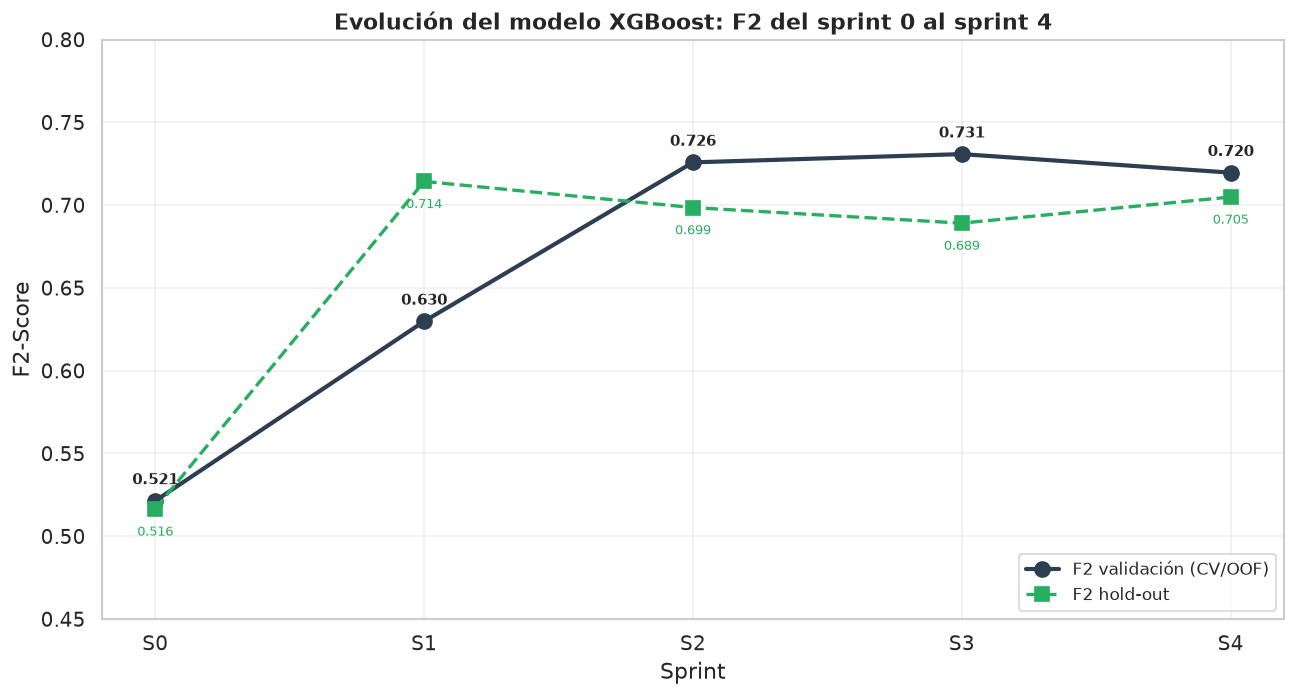

Guardado: evolucion_f2_sprints.png


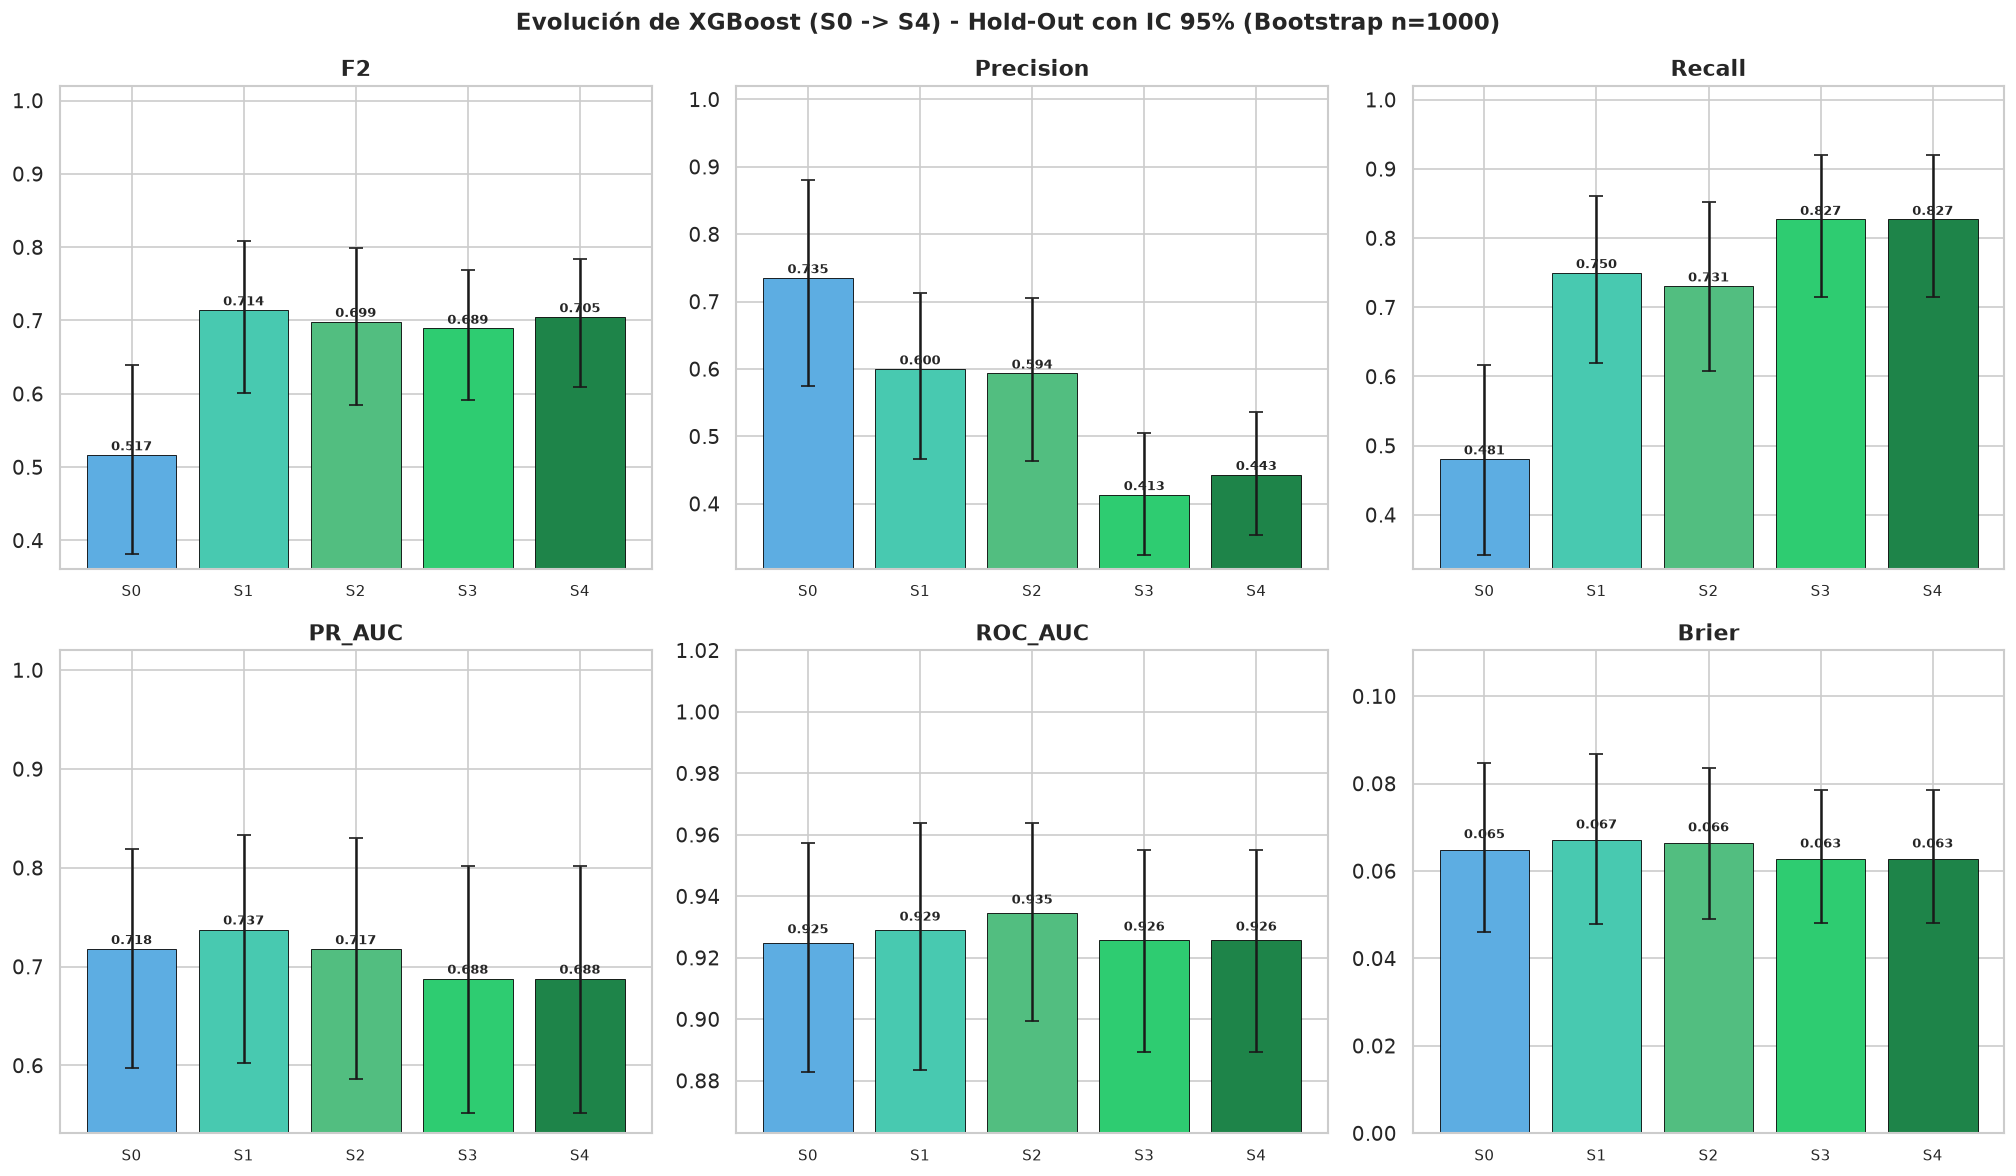

Guardado: comparativo_barras_ic95.png


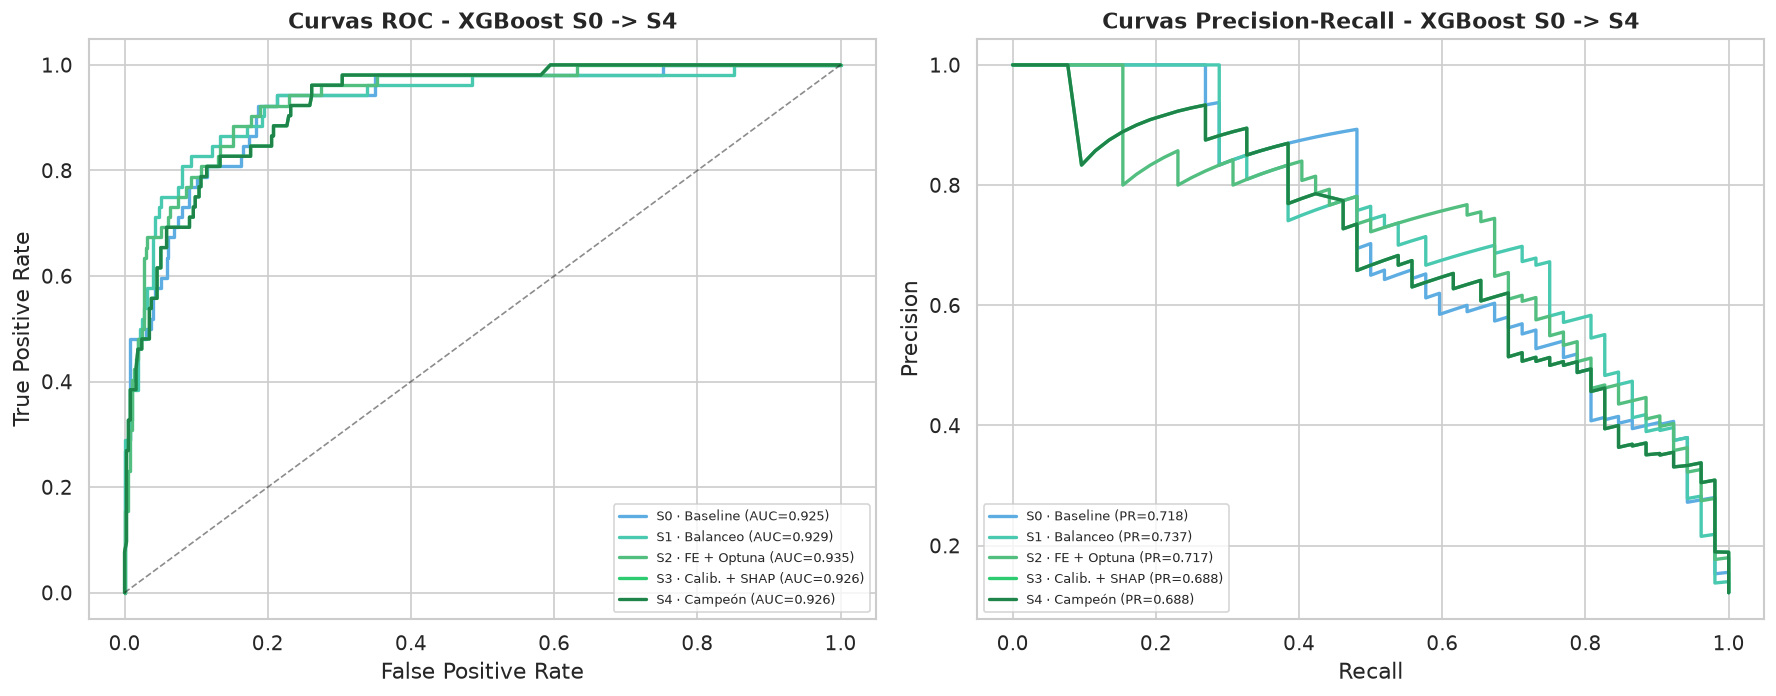

Guardado: curvas_roc_pr_comparativo.png


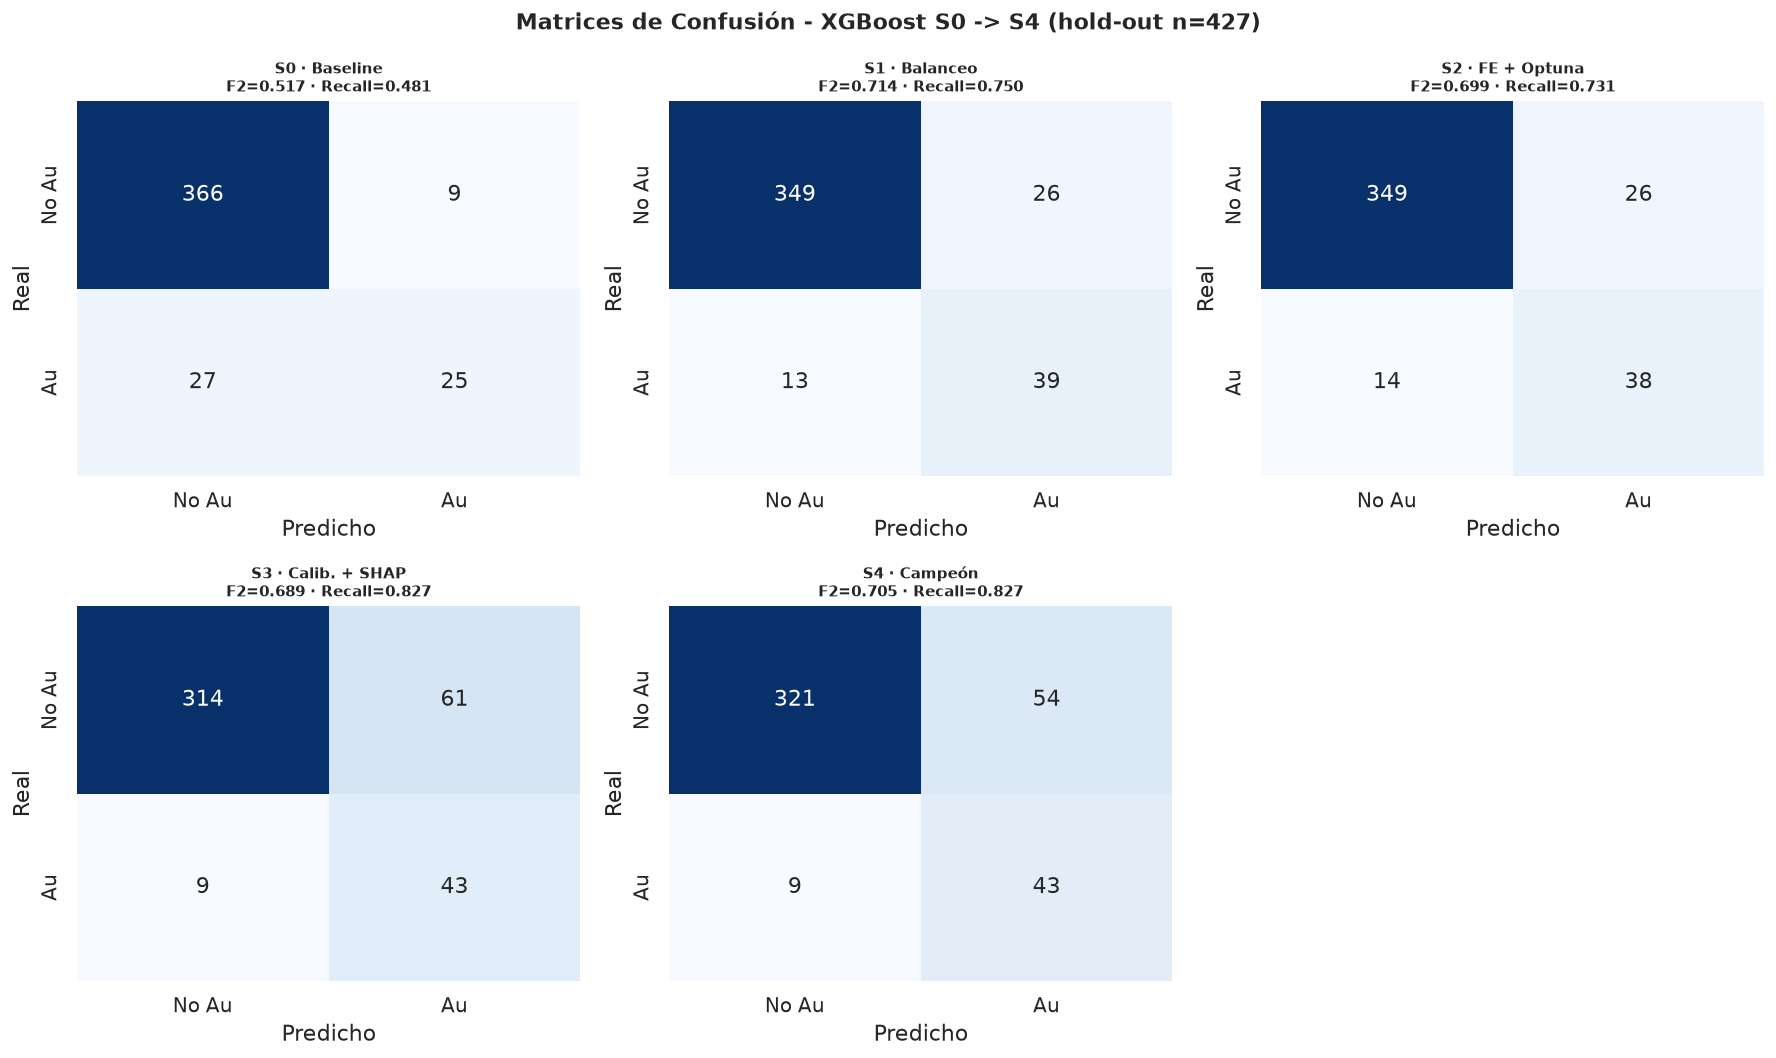

Guardado: matrices_confusion_comparativo.png


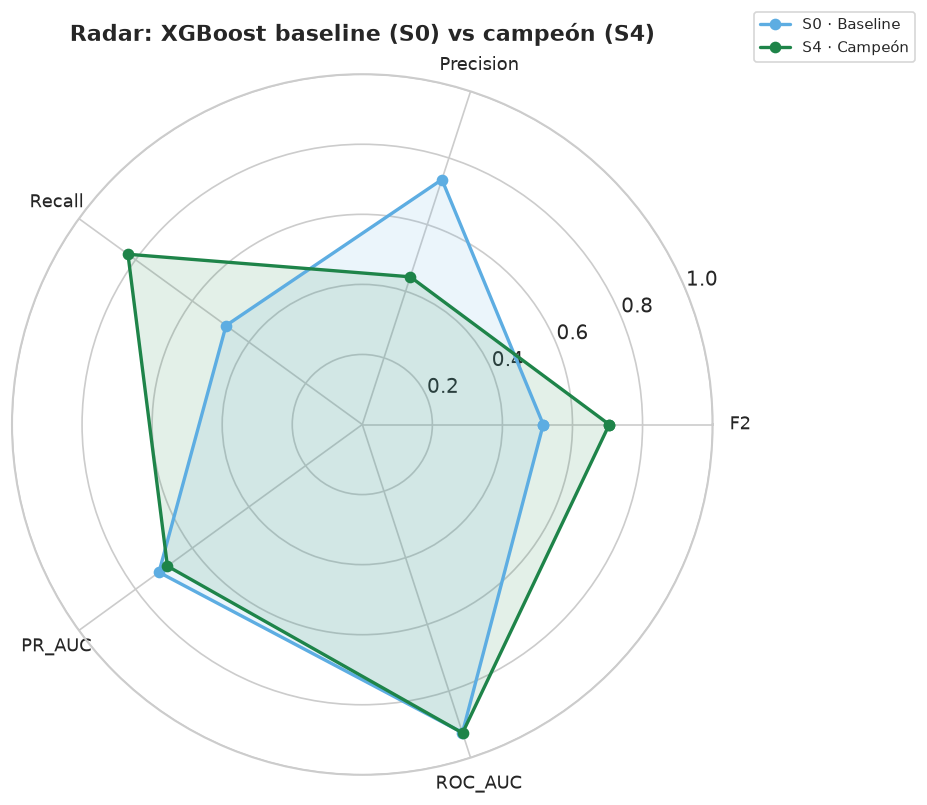

Guardado: radar_comparativo.png


In [10]:
# Paleta en gradiente (azul -> verde) para reflejar la progresión S0 -> S4
nombres_modelos = list(resultados_pred.keys())
colores = ['#5dade2', '#48c9b0', '#52be80', '#2ecc71', '#1e8449']
etiquetas = [n.replace(' · ', '\n') for n in nombres_modelos]

# 0 Evolución de F2 (validación y hold-out) de XGBoost del sprint 0 al sprint 4
fig, ax = plt.subplots(figsize=(11, 6))
sprints = df_evol['Sprint'].tolist()
xpos = np.arange(len(sprints))
f2v = df_evol['F2 val.'].to_numpy(dtype=float)
f2h = df_evol['F2 hold-out'].to_numpy(dtype=float)
ax.plot(xpos, f2v, 'o-', color='#2c3e50', lw=2.5, markersize=9, label='F2 validación (CV/OOF)')
ax.plot(xpos, f2h, 's--', color='#27ae60', lw=2, markersize=8, label='F2 hold-out')
for xi, yv, yh in zip(xpos, f2v, f2h):
    ax.annotate(f'{yv:.3f}', (xi, yv), textcoords='offset points', xytext=(0, 10), ha='center', fontsize=9, fontweight='bold')
    ax.annotate(f'{yh:.3f}', (xi, yh), textcoords='offset points', xytext=(0, -16), ha='center', fontsize=8, color='#27ae60')
ax.set_xticks(xpos); ax.set_xticklabels(sprints)
ax.set_ylabel('F2-Score'); ax.set_xlabel('Sprint')
ax.set_title('Evolución del modelo XGBoost: F2 del sprint 0 al sprint 4', fontweight='bold', fontsize=13)
ax.set_ylim(0.45, 0.80); ax.legend(fontsize=10, loc='lower right'); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'evolucion_f2_sprints.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Guardado: evolucion_f2_sprints.png')

# 1 Barras con IC 95% - metricas hold-out de las 5 versiones de XGBoost
fig, axes = plt.subplots(2, 3, figsize=(17, 10))
fig.suptitle('Evolución de XGBoost (S0 -> S4) - Hold-Out con IC 95% (Bootstrap n=1000)', fontsize=14, fontweight='bold')
for idx, metrica in enumerate(metricas_clave):
    ax = axes[idx // 3, idx % 3]
    vals = [eval_results[n][metrica] for n in nombres_modelos]
    ci_lows = [eval_results[n][f'{metrica}_CI_low'] for n in nombres_modelos]
    ci_highs = [eval_results[n][f'{metrica}_CI_high'] for n in nombres_modelos]
    errors_low = [v - cl for v, cl in zip(vals, ci_lows)]
    errors_high = [ch - v for v, ch in zip(vals, ci_highs)]
    bars = ax.bar(range(len(nombres_modelos)), vals, color=colores,
                  yerr=[errors_low, errors_high], capsize=4, edgecolor='black', linewidth=0.5)
    ax.set_title(metrica, fontweight='bold')
    ax.set_xticks(range(len(nombres_modelos)))
    ax.set_xticklabels([f'S{i}' for i in range(5)], fontsize=9)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                f'{v:.3f}', ha='center', va='bottom', fontsize=8, fontweight='bold')
    if metrica == 'Brier':
        ax.set_ylim(0, max(vals) * 1.5 + 0.01)
    else:
        ax.set_ylim(max(0, min(ci_lows) - 0.02), 1.02)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'comparativo_barras_ic95.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Guardado: comparativo_barras_ic95.png')

# 2 Curvas ROC y Precision-Recall de las 5 versiones
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
for nombre, color in zip(nombres_modelos, colores):
    y_prob = resultados_pred[nombre]['y_prob']
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    ax1.plot(fpr, tpr, color=color, lw=2, label=f'{nombre} (AUC={eval_results[nombre]["ROC_AUC"]:.3f})')
    prec, rec, _ = precision_recall_curve(y_test, y_prob)
    ax2.plot(rec, prec, color=color, lw=2, label=f'{nombre} (PR={eval_results[nombre]["PR_AUC"]:.3f})')
ax1.plot([0,1], [0,1], 'k--', lw=1, alpha=0.5)
ax1.set_xlabel('False Positive Rate'); ax1.set_ylabel('True Positive Rate')
ax1.set_title('Curvas ROC - XGBoost S0 -> S4', fontweight='bold'); ax1.legend(fontsize=8, loc='lower right')
ax2.set_xlabel('Recall'); ax2.set_ylabel('Precision')
ax2.set_title('Curvas Precision-Recall - XGBoost S0 -> S4', fontweight='bold'); ax2.legend(fontsize=8, loc='lower left')
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'curvas_roc_pr_comparativo.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Guardado: curvas_roc_pr_comparativo.png')

# 3 Matrices de confusion de las 5 versiones
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
fig.suptitle(f'Matrices de Confusión - XGBoost S0 -> S4 (hold-out n={len(y_test)})', fontsize=13, fontweight='bold')
for idx, (nombre, preds) in enumerate(resultados_pred.items()):
    ax = axes[idx // 3, idx % 3]
    cm = confusion_matrix(y_test, preds['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['No Au', 'Au'], yticklabels=['No Au', 'Au'], cbar=False)
    ax.set_title(f'{nombre}\nF2={eval_results[nombre]["F2"]:.3f} · Recall={eval_results[nombre]["Recall"]:.3f}', fontsize=9, fontweight='bold')
    ax.set_ylabel('Real'); ax.set_xlabel('Predicho')
axes[1, 2].axis('off')
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'matrices_confusion_comparativo.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Guardado: matrices_confusion_comparativo.png')

# 4 Radar comparativo (S0 baseline vs S4 campeón, para leer el salto neto)
metricas_radar = ['F2', 'Precision', 'Recall', 'PR_AUC', 'ROC_AUC']
angles = np.linspace(0, 2*np.pi, len(metricas_radar), endpoint=False).tolist()
angles += angles[:1]
fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
for nombre, color in [(nombres_modelos[0], '#5dade2'), (nombres_modelos[-1], '#1e8449')]:
    vals = [eval_results[nombre][m] for m in metricas_radar]
    vals += vals[:1]
    ax.plot(angles, vals, 'o-', color=color, linewidth=2, label=nombre)
    ax.fill(angles, vals, alpha=0.12, color=color)
ax.set_xticks(angles[:-1]); ax.set_xticklabels(metricas_radar, fontsize=11)
ax.set_ylim(0.0, 1.0); ax.set_rlabel_position(22.5)
ax.yaxis.set_major_locator(mticker.MaxNLocator(5))
ax.set_title('Radar: XGBoost baseline (S0) vs campeón (S4)', fontsize=13, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'radar_comparativo.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Guardado: radar_comparativo.png')

# Análisis de ganancia: Baseline -> Actual

=== GANANCIA: XGBoost S0 (baseline) -> XGBoost S4 (campeón) ===
  Metrica XGBoost S0 XGBoost S4 Delta Absoluto Delta Relativo (%)        IC 95% S0        IC 95% S4
       F2     0.5165     0.7049        +0.1884            +36.47% [0.3813, 0.6397] [0.6093, 0.7840]
Precision     0.7353     0.4433        -0.2920            -39.71% [0.5749, 0.8801] [0.3529, 0.5361]
   Recall     0.4808     0.8269        +0.3462            +72.00% [0.3421, 0.6170] [0.7143, 0.9200]
   PR_AUC     0.7176     0.6876        -0.0300             -4.18% [0.5970, 0.8191] [0.5515, 0.8018]
  ROC_AUC     0.9249     0.9258        +0.0009             +0.09% [0.8829, 0.9574] [0.8895, 0.9549]
    Brier     0.0648     0.0626        -0.0021             -3.29% [0.0460, 0.0847] [0.0481, 0.0786]


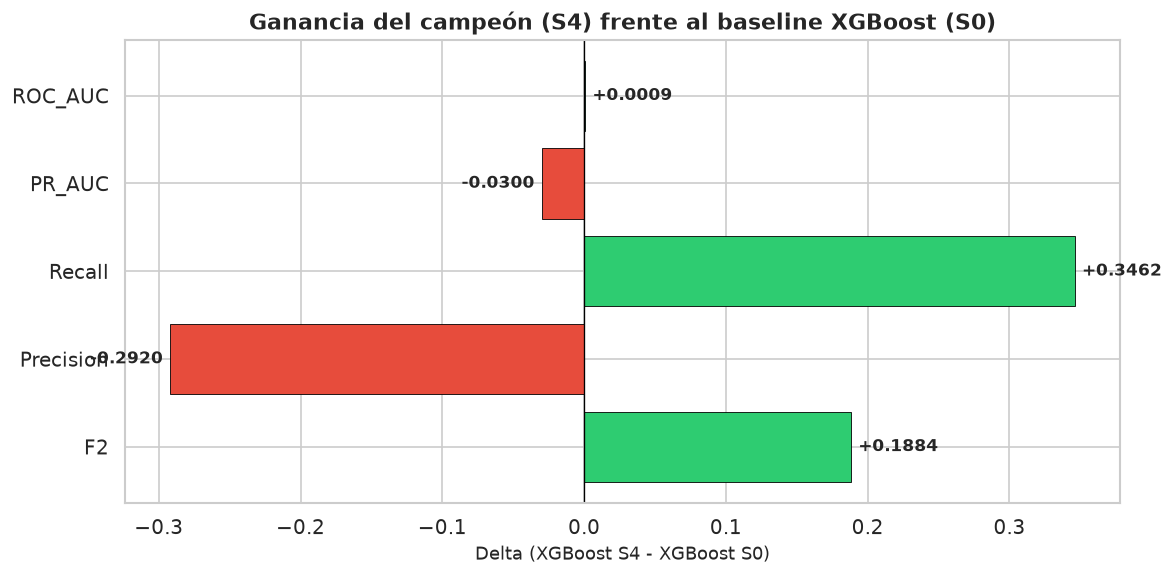

Guardado: delta_ganancia.png


In [11]:
# Delta entre la PRIMERA versión de XGBoost (S0, baseline) y la ÚLTIMA (S4, campeón final)
baseline_name = nombres_modelos[0]   # 'S0 · Baseline'
actual_name   = nombres_modelos[-1]  # 'S4 · Campeón'

rows_delta = []
for m in metricas_clave:
    val_bl = eval_results[baseline_name][m]
    val_act = eval_results[actual_name][m]
    delta = val_act - val_bl
    pct = (delta / val_bl * 100) if val_bl != 0 else 0
    rows_delta.append({
        'Metrica': m,
        'XGBoost S0': f'{val_bl:.4f}',
        'XGBoost S4': f'{val_act:.4f}',
        'Delta Absoluto': f'{delta:+.4f}',
        'Delta Relativo (%)': f'{pct:+.2f}%',
        'IC 95% S0': f"[{eval_results[baseline_name][f'{m}_CI_low']:.4f}, {eval_results[baseline_name][f'{m}_CI_high']:.4f}]",
        'IC 95% S4': f"[{eval_results[actual_name][f'{m}_CI_low']:.4f}, {eval_results[actual_name][f'{m}_CI_high']:.4f}]",
    })

df_delta = pd.DataFrame(rows_delta)
df_delta.to_csv(os.path.join(OUT_DIR, 'delta_baseline_vs_final.csv'), index=False)
print('=== GANANCIA: XGBoost S0 (baseline) -> XGBoost S4 (campeón) ===')
print(df_delta.to_string(index=False))

# Grafico de deltas
fig, ax = plt.subplots(figsize=(10, 5))
metricas_plot = ['F2', 'Precision', 'Recall', 'PR_AUC', 'ROC_AUC']
deltas = [eval_results[actual_name][m] - eval_results[baseline_name][m] for m in metricas_plot]
colors_bar = ['#2ecc71' if d >= 0 else '#e74c3c' for d in deltas]
bars = ax.barh(metricas_plot, deltas, color=colors_bar, edgecolor='black', linewidth=0.5)
ax.axvline(x=0, color='black', linewidth=0.8)
ax.set_xlabel('Delta (XGBoost S4 - XGBoost S0)', fontsize=11)
ax.set_title('Ganancia del campeón (S4) frente al baseline XGBoost (S0)', fontweight='bold', fontsize=13)
for bar, d in zip(bars, deltas):
    ax.text(bar.get_width() + (0.005 if d >= 0 else -0.005), bar.get_y() + bar.get_height()/2,
            f'{d:+.4f}', va='center', ha='left' if d >= 0 else 'right', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'delta_ganancia.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Guardado: delta_ganancia.png')

# Tabla consolidada

In [12]:
consolidado = {
    'Metrica': [], 'XGBoost S0 (baseline)': [],
    'XGBoost S4 (campeón)': [], 'Delta': [], 'Veredicto': []
}

for m in ['F2', 'Precision', 'Recall', 'PR_AUC', 'ROC_AUC']:
    val_bl = eval_results[baseline_name][m]
    val_act = eval_results[actual_name][m]
    delta = val_act - val_bl
    consolidado['Metrica'].append(m)
    consolidado['XGBoost S0 (baseline)'].append(f'{val_bl:.4f} [{eval_results[baseline_name][f"{m}_CI_low"]:.4f}, {eval_results[baseline_name][f"{m}_CI_high"]:.4f}]')
    consolidado['XGBoost S4 (campeón)'].append(f'{val_act:.4f} [{eval_results[actual_name][f"{m}_CI_low"]:.4f}, {eval_results[actual_name][f"{m}_CI_high"]:.4f}]')
    consolidado['Delta'].append(f'{delta:+.4f}')
    consolidado['Veredicto'].append('Mejora' if delta > 0 else 'Sin cambio' if delta == 0 else 'Peor')

# Brier (menor = mejor); S0 no lo tiene calibrado, se calcula igual sobre sus probabilidades
val_bl = eval_results[baseline_name]['Brier']
val_act = eval_results[actual_name]['Brier']
delta = val_act - val_bl
consolidado['Metrica'].append('Brier Score')
consolidado['XGBoost S0 (baseline)'].append(f'{val_bl:.4f}')
consolidado['XGBoost S4 (campeón)'].append(f'{val_act:.4f}')
consolidado['Delta'].append(f'{delta:+.4f}')
consolidado['Veredicto'].append('Mejora' if delta < 0 else 'Sin cambio' if delta == 0 else 'Peor')

df_consolidado = pd.DataFrame(consolidado)
df_consolidado.to_csv(os.path.join(OUT_DIR, 'tabla_consolidada_final.csv'), index=False)

print('='*80)
print('TABLA CONSOLIDADA: XGBoost S0 (baseline) vs XGBoost S4 (campeón final)')
print('='*80)
print(df_consolidado.to_string(index=False))

TABLA CONSOLIDADA: XGBoost S0 (baseline) vs XGBoost S4 (campeón final)
    Metrica   XGBoost S0 (baseline)    XGBoost S4 (campeón)   Delta Veredicto
         F2 0.5165 [0.3813, 0.6397] 0.7049 [0.6093, 0.7840] +0.1884    Mejora
  Precision 0.7353 [0.5749, 0.8801] 0.4433 [0.3529, 0.5361] -0.2920      Peor
     Recall 0.4808 [0.3421, 0.6170] 0.8269 [0.7143, 0.9200] +0.3462    Mejora
     PR_AUC 0.7176 [0.5970, 0.8191] 0.6876 [0.5515, 0.8018] -0.0300      Peor
    ROC_AUC 0.9249 [0.8829, 0.9574] 0.9258 [0.8895, 0.9549] +0.0009    Mejora
Brier Score                  0.0648                  0.0626 -0.0021    Mejora


# Resumen

In [13]:
bl = eval_results[baseline_name]
act = eval_results[actual_name]

# Significancia: los IC 95% de F2 (métrica de decisión) del baseline S0 y del campeón S4
f2_significativo = act['F2_CI_low'] > bl['F2_CI_high']

print('='*70)
print('RESUMEN EJECUTIVO - EVOLUCIÓN DE XGBoost (SPRINT 0 -> SPRINT 4)')
print('='*70)
print('')
print('1. TRAYECTORIA DE XGBoost (F2 hold-out sobre el mismo test fijo):')
for _, r in df_evol.iterrows():
    print(f'   {r["Sprint"]}: F2_ho={r["F2 hold-out"]:.4f} | Recall={r["Recall"]:.4f} | Prec={r["Precision"]:.4f} | {r["Etapa de XGBoost"]}')
print('')
print('2. BASELINE S0 vs CAMPEÓN S4 (hold-out):')
print(f'   - F2-Score:  {bl["F2"]:.4f} -> {act["F2"]:.4f} (Delta = {act["F2"]-bl["F2"]:+.4f})')
print(f'   - Recall:    {bl["Recall"]:.4f} -> {act["Recall"]:.4f} (Delta = {act["Recall"]-bl["Recall"]:+.4f})')
print(f'   - Precision: {bl["Precision"]:.4f} -> {act["Precision"]:.4f} (Delta = {act["Precision"]-bl["Precision"]:+.4f})')
print(f'   - PR-AUC:    {bl["PR_AUC"]:.4f} -> {act["PR_AUC"]:.4f} (Delta = {act["PR_AUC"]-bl["PR_AUC"]:+.4f})')
print('')
print('3. LECTURA DE LA EVOLUCIÓN:')
print('   - El balanceo (S1) da el mayor salto inicial en Recall/F2 sobre el baseline sin balanceo.')
print('   - S2-S3 incorporan FE, selección SHAP, calibración y umbral orientado a F2: el Recall sube')
print('     con fuerza (detectar más zonas de interés) a costa de precisión, coherente con priorizar F2.')
print('   - S4 fija un umbral GLOBAL anidado y valida por slices con IC95: recupera precisión frente a S3')
print('     manteniendo el Recall alto -> es la versión desplegable (campeón).')
print('')
print('4. SIGNIFICANCIA ESTADÍSTICA (F2, bootstrap IC 95%):')
print(f'   - IC 95% F2 XGBoost S0: [{bl["F2_CI_low"]:.4f}, {bl["F2_CI_high"]:.4f}]')
print(f'   - IC 95% F2 XGBoost S4: [{act["F2_CI_low"]:.4f}, {act["F2_CI_high"]:.4f}]')
print(f'   - IC no se solapan?    : {"SI -> mejora estadisticamente significativa" if f2_significativo else "NO -> la mejora no es concluyente al 95%"}')
print('')
print('5. NOTA DE ALCANCE:')
print('   - Se comparó la MISMA familia (XGBoost) a lo largo de los 5 sprints; no se adoptó stacking:')
print('     el ensemble A1 del sprint 4 no superó al XGBoost calibrado en F2 OOF.')
print('')

# Guardar resumen en TXT
with open(os.path.join(OUT_DIR, 'resumen_ejecutivo.txt'), 'w') as f:
    f.write('RESUMEN EJECUTIVO - EVOLUCIÓN DE XGBoost (SPRINT 0 -> SPRINT 4)\n')
    f.write(f'Baseline: {baseline_name} | Campeón: {actual_name}\n\n')
    f.write('Trayectoria hold-out (mismo test fijo, n=427, 52 positivos):\n')
    for _, r in df_evol.iterrows():
        f.write(f'  {r["Sprint"]}: F2_val={r["F2 val."]:.4f} ({r["val."]}) | F2_ho={r["F2 hold-out"]:.4f} | '
                f'Recall={r["Recall"]:.4f} | Prec={r["Precision"]:.4f} | umbral={r["umbral"]:.4f} | {r["Etapa de XGBoost"]}\n')
    f.write(f'\nF2 hold-out: {bl["F2"]:.4f} (S0) -> {act["F2"]:.4f} (S4) (Delta={act["F2"]-bl["F2"]:+.4f})\n')
    f.write(f'Recall hold-out: {bl["Recall"]:.4f} -> {act["Recall"]:.4f}\n')
    f.write(f'Precision hold-out: {bl["Precision"]:.4f} -> {act["Precision"]:.4f}\n')
    f.write(f'IC 95% F2 S0: [{bl["F2_CI_low"]:.4f}, {bl["F2_CI_high"]:.4f}]\n')
    f.write(f'IC 95% F2 S4: [{act["F2_CI_low"]:.4f}, {act["F2_CI_high"]:.4f}]\n')
    f.write(f'Mejora significativa (IC F2 no solapan): {f2_significativo}\n')
    f.write('Se comparó la misma familia (XGBoost) en los 5 sprints; no se adoptó stacking (A1 no superó al XGBoost calibrado en F2 OOF).\n')

print('Resumen guardado en outputs_sprint4_comparativo/resumen_ejecutivo.txt')

RESUMEN EJECUTIVO - EVOLUCIÓN DE XGBoost (SPRINT 0 -> SPRINT 4)

1. TRAYECTORIA DE XGBoost (F2 hold-out sobre el mismo test fijo):
   S0: F2_ho=0.5165 | Recall=0.4808 | Prec=0.7353 | Baseline: 43 features crudas, sin balanceo
   S1: F2_ho=0.7143 | Recall=0.7500 | Prec=0.6000 | Balanceo SMOTE + PCA por bloques
   S2: F2_ho=0.6985 | Recall=0.7308 | Prec=0.5938 | FE epitermal + cluster + Optuna (set E2)
   S3: F2_ho=0.6891 | Recall=0.8269 | Prec=0.4135 | Selección SHAP (28) + re-Optuna + calibración isotónica + umbral anidado
   S4: F2_ho=0.7049 | Recall=0.8269 | Prec=0.4433 | Umbral GLOBAL anidado + validación por slices e IC95 (campeón)

2. BASELINE S0 vs CAMPEÓN S4 (hold-out):
   - F2-Score:  0.5165 -> 0.7049 (Delta = +0.1884)
   - Recall:    0.4808 -> 0.8269 (Delta = +0.3462)
   - Precision: 0.7353 -> 0.4433 (Delta = -0.2920)
   - PR-AUC:    0.7176 -> 0.6876 (Delta = -0.0300)

3. LECTURA DE LA EVOLUCIÓN:
   - El balanceo (S1) da el mayor salto inicial en Recall/F2 sobre el baseline si

# Lista de artefactos generados

In [14]:
print('\n=== ARTEFACTOS GENERADOS ===')
for f in sorted(os.listdir(OUT_DIR)):
    size = os.path.getsize(os.path.join(OUT_DIR, f))
    print(f'  {f} ({size/1024:.1f} KB)')


=== ARTEFACTOS GENERADOS ===
  comparativo_barras_ic95.png (168.5 KB)
  comparativo_holdout_ic95.csv (1.0 KB)
  curvas_roc_pr_comparativo.png (168.9 KB)
  delta_baseline_vs_final.csv (0.5 KB)
  delta_ganancia.png (49.0 KB)
  evolucion_f2_sprints.png (88.8 KB)
  evolucion_sprints.csv (0.6 KB)
  matrices_confusion_comparativo.png (124.9 KB)
  radar_comparativo.png (174.4 KB)
  resumen_ejecutivo.txt (1.2 KB)
  tabla_consolidada_final.csv (0.5 KB)
